# An example ML project: develop a model for atomization energy

### Chem 190/290, Spring 2026, Liang Shi

### Dataset: QM7 (https://quantum-machine.org/datasets/)

This is a database composed of all molecules of up to 23 atoms (including 7 heavy atoms C, N, O, and S), totalling 7165 molecules. The dataset file constains the Coulomb matrix representation of these molecules and their atomization energies computed similarly to the FHI-AIMS implementation of the Perdew-Burke-Ernzerhof hybrid functional (PBE0). This dataset features a large variety of molecular structures such as double and triple bonds, cycles, carboxy, cyanide, amide, alcohol and epoxy. The dataset contains three multidimensional arrays X (7165 x 23 x 23) and T (7165) representing the inputs (Coulomb matrices) and the labels (atomization energies), respectively. The dataset is in the matlab format. 

Coulomb matrix: 
$$ C_{ii} = 0.5Z_i^{2.4}, $$
and for $i \neq j$,
$$ C_{ij} = Z_i Z_j / r_{ij}, $$
where $Z_i$ is the atomic number, and $r_{ij}$ is the distance between two atoms.

In [213]:
import os
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

from tqdm import tqdm, trange
from scipy.io import loadmat
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [214]:
%matplotlib inline

In [215]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [216]:
############################################
# Set random seed for reproducibility
############################################

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [224]:
############################################
# Download dataset
############################################

url = "http://quantum-machine.org/data/qm7.mat"
filename = "qm7.mat"

if not os.path.exists(filename):
    print("Downloading QM7 dataset...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")

In [225]:
############################################
# Load QM7 dataset
############################################
#  The dataset contains three multidimensional arrays X (7165 x 23 x 23) and T (7165) representing the inputs (Coulomb matrices) and the labels (atomization energies), respectively.

data = loadmat("qm7.mat")

# Coulomb matrices
X = data["X"]  # shape (7165, 23, 23)

# Atomization energy (kcal/mol)
y = data["T"].flatten()

# flatten Coulomb matrix
X = X.reshape(len(X), -1)

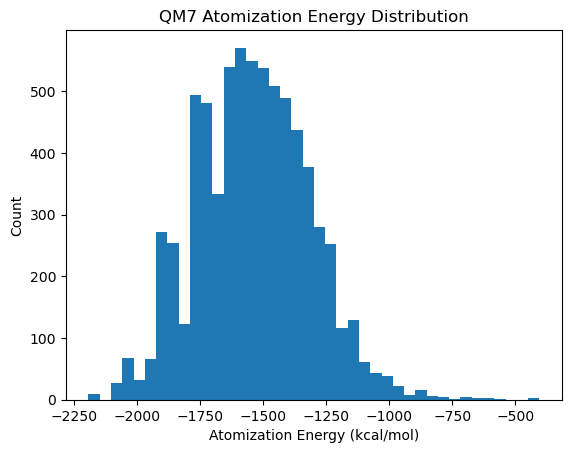

In [226]:
############################################
# Histogram of atomization energies
############################################

plt.figure()
plt.hist(y, bins=40)
plt.xlabel("Atomization Energy (kcal/mol)")
plt.ylabel("Count")
plt.title("QM7 Atomization Energy Distribution")
plt.show()

In [227]:
############################################
# Show first five datapoints
############################################

print("\nFirst five datapoints:\n")

for i in range(5):
    # print(f"Datapoint {i+1}")
    print(f"Atomization Energy = {y[i]:.3f} kcal/mol")
    print("First 10 Coulomb matrix features:", X[i][:10])
    print()


First five datapoints:

Atomization Energy = -417.960 kcal/mol
First 10 Coulomb matrix features: [36.858105   2.9076326  2.907612   2.9075644  2.9053485  0.
  0.         0.         0.         0.       ]

Atomization Energy = -712.420 kcal/mol
First 10 Coulomb matrix features: [36.858105  12.599944   2.9019997  1.4731182  1.4731014  2.9019725
  2.9018855  1.4731016  0.         0.       ]

Atomization Energy = -564.210 kcal/mol
First 10 Coulomb matrix features: [36.858105  14.261827   1.503703   2.9249973  2.9247324  1.5036802
  0.         0.         0.         0.       ]

Atomization Energy = -404.880 kcal/mol
First 10 Coulomb matrix features: [36.858105  15.871878   2.9794335  1.4012247  0.         0.
  0.         0.         0.         0.       ]

Atomization Energy = -808.870 kcal/mol
First 10 Coulomb matrix features: [73.51669   17.885317  10.56149    4.355064   2.0625298  2.069614
  1.5819906  1.59078    1.2614818  0.       ]



In [228]:
#############################################
# Sorted Coulomb matrix feature generation
#############################################

# Sorted Coulomb matrix ensures the invariance of the features to the atom permutation
# Ref: https://proceedings.neurips.cc/paper_files/paper/2012/file/115f89503138416a242f40fb7d7f338e-Paper.pdf

def sorted_coulomb_features(C):
    feats = []
    for m in C:
        row_norms = np.linalg.norm(m, axis=1)
        idx = np.argsort(-row_norms)
        m_sorted = m[idx][:, idx]
        feats.append(m_sorted[np.triu_indices_from(m_sorted)])
    return np.array(feats)

X = sorted_coulomb_features(C)

In [229]:
############################################
# Train / Validation / Test split (8:1:1)
############################################

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.1, random_state=seed
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.111111, random_state=seed
)
print(y_test[1]) # check reproducibility

-1482.66


In [230]:
############################################
# Normalization using StandardScaler
############################################

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_val = X_scaler.transform(X_val)
X_test = X_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train.reshape(-1,1))
y_val = y_scaler.transform(y_val.reshape(-1,1))
y_test = y_scaler.transform(y_test.reshape(-1,1))

In [231]:
############################################
# Convert to PyTorch tensors
############################################

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

In [251]:
############################################
# Define FFNN
############################################

class FFNN(nn.Module):
    def __init__(self, input_dim, seed=None):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )
        self.initialize_weights(seed)

    def initialize_weights(self, seed=None):
        if seed is not None:
            # Set seed for reproducible weight initialization
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed(seed)
                torch.cuda.manual_seed_all(seed)
        # He initialization for Linear layers
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)

In [252]:
def print_model_parameters(model):
    total_params = 0
    print(f"{'Layer':<20} {'Weights':>10} {'Biases':>10} {'Total':>10}")
    print("-" * 55)
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            weight_params = module.weight.numel()
            bias_params = module.bias.numel() if module.bias is not None else 0
            layer_total = weight_params + bias_params
            total_params += layer_total
            print(f"{name:<20} {weight_params:>10,} {bias_params:>10,} {layer_total:>10,}")
    
    print("-" * 55)
    print(f"{'Total':<20} {'':>10} {'':>10} {total_params:>10,}")

# Example usage
model = FFNN(input_dim=X.shape[1], seed=seed).to(device)
print_model_parameters(model)

Layer                   Weights     Biases      Total
-------------------------------------------------------
model.0                 110,400        400    110,800
model.2                  40,000        100     40,100
model.4                     100          1        101
-------------------------------------------------------
Total                                         151,001


In [253]:
############################################
# 3-fold Cross Validation for Learning Rate
############################################
learning_rates = [1e-3,3e-3,1e-2,3e-2,1e-1]
kf = KFold(n_splits=3, shuffle=True, random_state=seed)

best_lr = None
best_loss = np.inf

max_epochs = 500

for lr in learning_rates:
    fold_losses = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr = torch.tensor(X_train[train_idx], dtype=torch.float32).to(device)
        y_tr = torch.tensor(y_train[train_idx], dtype=torch.float32).to(device)
        X_va = torch.tensor(X_train[val_idx], dtype=torch.float32).to(device)
        y_va = torch.tensor(y_train[val_idx], dtype=torch.float32).to(device)

        model = FFNN(X.shape[1], seed=seed).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
        loss_fn = nn.MSELoss()

        for epoch in range(max_epochs):
            model.train()
            optimizer.zero_grad()
            pred = model(X_tr)
            loss = loss_fn(pred, y_tr)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_val = model(X_va)
            val_loss = nn.MSELoss()(pred_val, y_va).item()
        fold_losses.append(val_loss)

    avg_loss = np.mean(fold_losses)
    print(f"Learning rate {lr}: CV Loss = {avg_loss:.6f}")
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_lr = lr

print(f"Best learning rate: {best_lr}")

Learning rate 0.001: CV Loss = 0.059398
Learning rate 0.003: CV Loss = 0.018460
Learning rate 0.01: CV Loss = 0.013563
Learning rate 0.03: CV Loss = 0.025624
Learning rate 0.1: CV Loss = 0.824329
Best learning rate: 0.01


In [254]:
############################################
# Final Training with Early Stopping for Best Model
############################################
max_epochs = 4000
counter = 0
best_val_rmse = np.inf
best_model_state = None

model = FFNN(X.shape[1], seed=seed).to(device) 
optimizer = optim.Adam(model.parameters(), lr=best_lr, weight_decay=1e-5)
loss_fn = nn.MSELoss()

train_rmse_list = []
val_rmse_list = []

best_lr = 0.01

for epoch in range(max_epochs):
    model.train() # training mode
    optimizer.zero_grad() # clear all the gradients
    pred_train = model(X_train_t) # forward pass
    loss_train = loss_fn(pred_train, y_train_t) # compute loss function
    loss_train.backward() # compute gradients using backpropagation
    optimizer.step() # update model parameters

    # Evaluate RMSE in original units
    model.eval() # evaluation mode
    with torch.no_grad(): # turn off gradient calculation, which is not needed for val/test sets.
        pred_train_orig = y_scaler.inverse_transform(pred_train.cpu().numpy()) # move result from GPU to CPU, and convert it to np array
        y_train_orig = y_scaler.inverse_transform(y_train_t.cpu().numpy())
        train_rmse = np.sqrt(mean_squared_error(y_train_orig.flatten(), pred_train_orig.flatten()))
        train_rmse_list.append(train_rmse)

        pred_val = model(X_val_t)
        pred_val_orig = y_scaler.inverse_transform(pred_val.cpu().numpy())
        y_val_orig = y_scaler.inverse_transform(y_val_t.cpu().numpy())
        val_rmse = np.sqrt(mean_squared_error(y_val_orig.flatten(), pred_val_orig.flatten()))
        val_rmse_list.append(val_rmse)

        # Save best model based on validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_state = model.state_dict()
            best_epoch = epoch + 1  # +1 because epoch starts from 0
            counter = 0
        else:
            counter += 1

    # Print every 100 epochs
    if (epoch + 1) % 500 == 0:
        tqdm.write(f"Epoch {epoch+1}/{max_epochs} | Train RMSE: {train_rmse:.3f} kcal/mol | Val RMSE: {val_rmse:.3f} kcal/mol")

# Load best model
model.load_state_dict(best_model_state)
print(f"Best model obtained at epoch {best_epoch} with validation RMSE = {best_val_rmse:.3f} kcal/mol")

Epoch 500/4000 | Train RMSE: 22.416 kcal/mol | Val RMSE: 24.406 kcal/mol
Epoch 1000/4000 | Train RMSE: 14.653 kcal/mol | Val RMSE: 20.030 kcal/mol
Epoch 1500/4000 | Train RMSE: 9.608 kcal/mol | Val RMSE: 17.901 kcal/mol
Epoch 2000/4000 | Train RMSE: 9.375 kcal/mol | Val RMSE: 18.737 kcal/mol
Epoch 2500/4000 | Train RMSE: 8.621 kcal/mol | Val RMSE: 18.439 kcal/mol
Epoch 3000/4000 | Train RMSE: 5.017 kcal/mol | Val RMSE: 16.104 kcal/mol
Epoch 3500/4000 | Train RMSE: 4.766 kcal/mol | Val RMSE: 16.030 kcal/mol
Epoch 4000/4000 | Train RMSE: 6.802 kcal/mol | Val RMSE: 16.073 kcal/mol
Best model obtained at epoch 3936 with validation RMSE = 15.662 kcal/mol


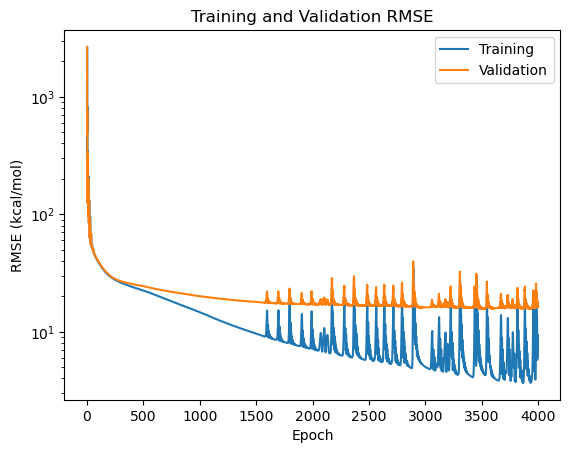

In [255]:
############################################
# Plot Training and Validation RMSE
############################################
plt.figure()
plt.plot(train_rmse_list, label="Training")
plt.plot(val_rmse_list, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE (kcal/mol)")
plt.yscale('log')  # log scale for y-axis
plt.title("Training and Validation RMSE")
plt.legend()
plt.show()

In [256]:
def evaluate(model, X_t, y_t):
    model.eval()
    with torch.no_grad():
        # get predictions in scaled units
        pred_scaled = model(X_t).cpu().numpy()
        # inverse transform to kcal/mol
        y_true_orig = y_scaler.inverse_transform(y_t.cpu().numpy())
        pred_orig = y_scaler.inverse_transform(pred_scaled)

    # flatten arrays
    y_true_orig = y_true_orig.flatten()
    pred_orig = pred_orig.flatten()

    # compute metrics
    mse = mean_squared_error(y_true_orig, pred_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_orig, pred_orig)

    # correlation coefficient using np.corrcoef
    r = np.corrcoef(y_true_orig, pred_orig)[0,1]

    # ensure Python floats for printing
    return float(rmse), float(mae), float(r), y_true_orig, pred_orig

train_metrics = evaluate(model, X_train_t, y_train_t)
val_metrics   = evaluate(model, X_val_t, y_val_t)
test_metrics  = evaluate(model, X_test_t, y_test_t)

print("\nPerformance (kcal/mol):")
print(f"Train: RMSE={train_metrics[0]:.3f}, MAE={train_metrics[1]:.3f}, r={train_metrics[2]:.3f}")
print(f"Validation: RMSE={val_metrics[0]:.3f}, MAE={val_metrics[1]:.3f}, r={val_metrics[2]:.3f}")
print(f"Test: RMSE={test_metrics[0]:.3f}, MAE={test_metrics[1]:.3f}, r={test_metrics[2]:.3f}")


Performance (kcal/mol):
Train: RMSE=4.880, MAE=3.534, r=1.000
Validation: RMSE=16.073, MAE=12.290, r=0.997
Test: RMSE=16.836, MAE=12.562, r=0.997


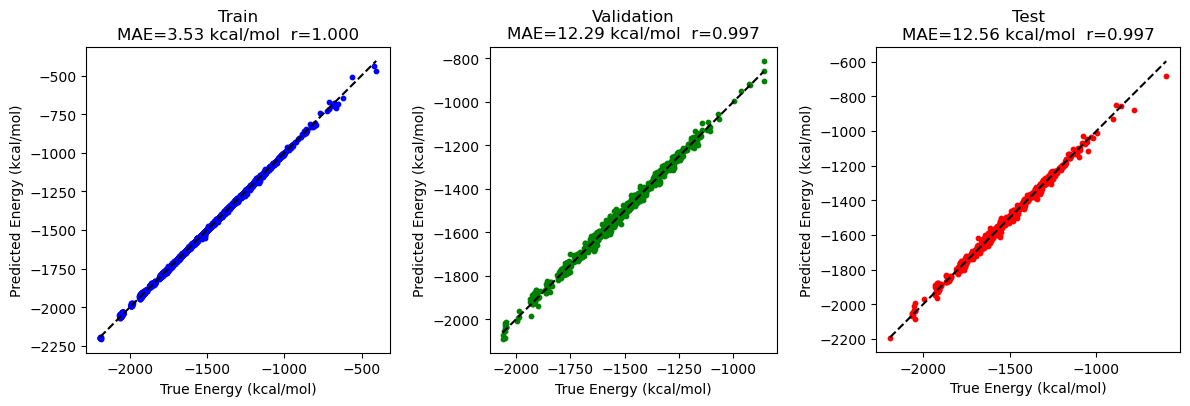

In [257]:
############################################
# Parity plots
############################################
fig, axes = plt.subplots(1,3,figsize=(12,4))
datasets = [
    ("Train", train_metrics, "blue"),
    ("Validation", val_metrics, "green"),
    ("Test", test_metrics, "red")
]

for ax, (name, data, color) in zip(axes, datasets):
    rmse, mae, r, y_true, pred = data
    ax.scatter(y_true, pred, s=10, color=color)
    ax.plot([y_true.min(), y_true.max()],
            [y_true.min(), y_true.max()], 'k--')
    ax.set_xlabel("True Energy (kcal/mol)")
    ax.set_ylabel("Predicted Energy (kcal/mol)")
    ax.set_title(f"{name}\nMAE={mae:.2f} kcal/mol  r={r:.3f}")
    ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()

Our results seem to be comparable to those in https://link.springer.com/article/10.1134/S0018143924701017

More systematic hyperparameter tuning: use other packages, e.g., https://docs.pytorch.org/tutorials/beginner/hyperparameter_tuning_tutorial.html